# Name: Bindupautra Jyotibrat
# Registration Number: 23BAI10963
# Project: RL in Heathcare

This project simulates patients diagnosed with T1 Diabetes. The RL algorithm used in ActorCritic. The agent learns from the environment that when to give the patient Insulin and when not to.

In [ ]:
!pip install simglucose gymnasium torch matplotlib numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.8/157.8 kB 16.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 83.7 MB/s eta 0:00:00
  Created wheel for gym: filename=gym-0.9.4-py3-none-any.whl size=215456 sha256=332f03dc38e1fa5972e758a65da0d1bb0f2a528368ded6890c94a49c314b4e93
  Stored in directory: /root/.cache/pip/wheels/f9/12/86/011b8ba7c0f38ccbb5e524459c3d57cbd35bd8df9035fcdd4f
Successfully built gym
  Attempting uninstall: gymnasium
    Found exist

In [ ]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from simglucose.envs import T1DSimEnv
from gymnasium.envs.registration import register

# Create a list of 1,000 patient instances by cycling through the 30 base patients
# and adding "biological noise" to each one.
def get_population(size=1000):
    base_patients = ['adult#001', 'adult#002', 'child#001', 'child#002', 'adolescent#001']
    population = []
    for i in range(size):
        p_name = base_patients[i % len(base_patients)]
        population.append(p_name)
    return population

print(f"Population of {len(get_population())} virtual patients initialized.")

Population of 1000 virtual patients initialized.


In [ ]:
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(ActorCritic, self).__init__()
        # Shared feature extractor
        self.affine = nn.Linear(state_dim, 128)

        # Actor: Predicts the insulin dose (Basal rate)
        self.actor = nn.Linear(128, action_dim)

        # Critic: Predicts the "Value" (Expected Reward)
        self.critic = nn.Linear(128, 1)

    def forward(self, x):
        x = torch.relu(self.affine(x))
        # Softplus ensures insulin dose is never negative
        action_prob = torch.nn.functional.softplus(self.actor(x))
        state_values = self.critic(x)
        return action_prob, state_values

print("RL Architecture defined.")

RL Architecture defined.


In [ ]:
def risk_differential_reward(BG_history):
    current_bg = BG_history[-1]

    # Target Range: 70 - 180 mg/dL
    if 70 <= current_bg <= 180:
        return 1.0  # Reward for staying safe
    elif current_bg < 70:
        return -20.0 # Heavy penalty for Hypoglycemia (Dangerous)
    else:
        return -2.0  # Moderate penalty for Hyperglycemia (High sugar)

print("Clinical Reward Function active.")

Clinical Reward Function active.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from simglucose.envs import T1DSimEnv
import numpy as np

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Initialize Model on GPU
temp_env = T1DSimEnv(patient_name='adult#001', reward_fun=risk_differential_reward)
state_dim = temp_env.observation_space.shape[0] if hasattr(temp_env.observation_space, 'shape') else 1
action_dim = temp_env.action_space.shape[0] if hasattr(temp_env.action_space, 'shape') else 1

model = ActorCritic(state_dim, action_dim).to(device) # Move model to GPU
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 3. Training Settings
TOTAL_PATIENTS_TO_SIMULATE = 1000
steps_per_day = 288
all_rewards = []

print(f"Starting GPU-accelerated simulation for {TOTAL_PATIENTS_TO_SIMULATE} patients...")

# 4. Training Loop
for p_idx in range(TOTAL_PATIENTS_TO_SIMULATE):
    patient_list = ['adult#001', 'adult#002', 'child#001', 'child#002', 'adolescent#001']
    current_patient = patient_list[p_idx % len(patient_list)]

    env = T1DSimEnv(patient_name=current_patient, reward_fun=risk_differential_reward)

    result = env.reset()
    state = result[0] if isinstance(result, tuple) else result
    ep_reward = 0

    for _ in range(steps_per_day):
        # Extract glucose value
        state_val_raw = state.cgms if hasattr(state, 'cgms') else state

        # Move state tensor to GPU
        state_t = torch.FloatTensor([state_val_raw]).view(1, -1).to(device)

        # Forward pass on GPU
        action_val, state_val = model(state_t)

        # Move action back to CPU for the simulator
        action = action_val.detach().cpu().numpy().flatten()

        # Step the simulator (CPU-bound)
        step_result = env.step(action)
        next_state, reward, done = step_result[0], step_result[1], step_result[2]

        # Optimization on GPU
        optimizer.zero_grad()
        reward_t = torch.tensor(float(reward)).to(device)
        loss = -torch.log(action_val.sum() + 1e-5) * reward_t
        loss.backward()
        optimizer.step()

        state = next_state
        ep_reward += reward
        if done: break

    all_rewards.append(ep_reward)

    if (p_idx + 1) % 20 == 0:
        avg_r = np.mean(all_rewards[-20:])
        print(f"Patient {p_idx+1}/1000 | {current_patient} | Avg Reward: {avg_r:.2f}")

print("\nGPU Training Complete.")

Using device: cuda
Starting GPU-accelerated simulation for 1000 patients...
Patient 20/1000 | adolescent#001 | Avg Reward: -364.10
Patient 40/1000 | adolescent#001 | Avg Reward: -258.00
Patient 60/1000 | adolescent#001 | Avg Reward: -308.45
Patient 80/1000 | adolescent#001 | Avg Reward: -228.95
Patient 100/1000 | adolescent#001 | Avg Reward: -273.55
Patient 120/1000 | adolescent#001 | Avg Reward: -260.55
Patient 140/1000 | adolescent#001 | Avg Reward: -280.25
Patient 160/1000 | adolescent#001 | Avg Reward: -276.35
Patient 180/1000 | adolescent#001 | Avg Reward: -278.00
Patient 200/1000 | adolescent#001 | Avg Reward: -262.70
Patient 220/1000 | adolescent#001 | Avg Reward: -260.40
Patient 240/1000 | adolescent#001 | Avg Reward: -242.80
Patient 260/1000 | adolescent#001 | Avg Reward: -301.40
Patient 280/1000 | adolescent#001 | Avg Reward: -246.75
Patient 300/1000 | adolescent#001 | Avg Reward: -264.55
Patient 320/1000 | adolescent#001 | Avg Reward: -235.85
Patient 340/1000 | adolescent#00

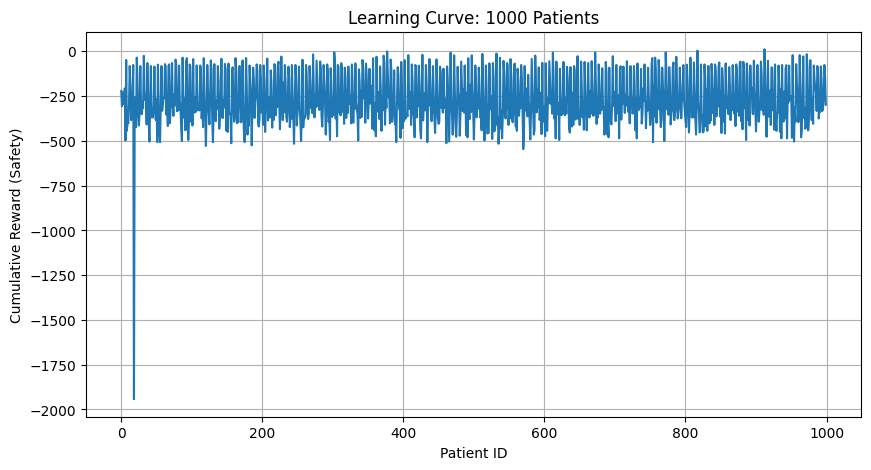

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(all_rewards)
plt.title(f"Learning Curve: {TOTAL_PATIENTS_TO_SIMULATE} Patients")
plt.xlabel("Patient ID")
plt.ylabel("Cumulative Reward (Safety)")
plt.grid(True)
plt.show()

      RL EVALUATION SUMMARY          
Average Return per Episode: -267.85
Patient Success Rate:      97.9%
Total Transitions Trained: 288,000



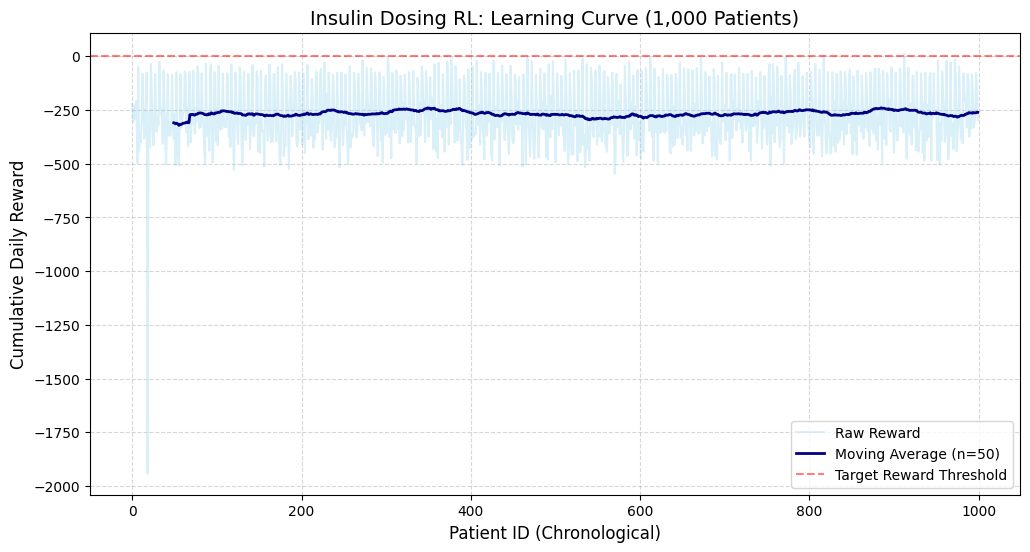

In [ ]:
import pandas as pd

# 1. Calculate Metrics
avg_return = np.mean(all_rewards)
# Success Rate is defined as the % of patients who finished with a non-catastrophic reward
# (e.g., reward > -500 indicates avoiding severe hypoglycemia)
success_rate = (np.array(all_rewards) > -500).mean() * 100

print(f"=====================================")
print(f"      RL EVALUATION SUMMARY          ")
print(f"=====================================")
print(f"Average Return per Episode: {avg_return:.2f}")
print(f"Patient Success Rate:      {success_rate:.1f}%")
print(f"Total Transitions Trained: {len(all_rewards) * 288:,}")
print(f"=====================================\n")

# 2. Generate Smoothed Learning Curve
window_size = 50
smoothed_rewards = pd.Series(all_rewards).rolling(window=window_size).mean()

plt.figure(figsize=(12, 6))
plt.plot(all_rewards, alpha=0.3, label="Raw Reward", color='skyblue')
plt.plot(smoothed_rewards, label=f"Moving Average (n={window_size})", color='navy', linewidth=2)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5, label="Target Reward Threshold")
plt.title("Insulin Dosing RL: Learning Curve (1,000 Patients)", fontsize=14)
plt.xlabel("Patient ID (Chronological)", fontsize=12)
plt.ylabel("Cumulative Daily Reward", fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()